Langkah 1 - Verifikasi Lingkungan Kerja

In [1]:
import sys, platform, multiprocessing
print("Python    :", sys.version.split()[0])
print("OS        :", platform.platform())
print("CPU core  :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")



Python    : 3.13.15
OS        : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core  : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       2.8Gi       3.5Mi       8.9Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Langkah 2 - Menghubungkan Google Drive dan menyiapkan struktur folder

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


Langkah 3 - Menyiapkan ukur waktu dan memori

In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

Langkah 4 - mengunduh dataset dan inspeksi awal

In [5]:
import urllib.request

URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

Ukuran file: 45.5 MB


In [6]:
import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


Langkah 5 - Memuat data dan mengukur biaya memorinya

In [7]:
import pandas as pd, gc

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()
df.info(memory_usage="deep")
print(df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2)

# Optimasi tipe data
sebelum = df.memory_usage(deep=True).sum() / 1024**2
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
print(df.dtypes)

[baca semua kolom] 1.36 s | RSS delta: +497.7 MB
Dimensi: (3066766, 19)
Memori: 565.6 MB
[baca kolom terpilih] 0.58 s | RSS delta: +204.9 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB
tpep_pickup_datetime     23.397568
payment_type             23.397568
tpep_dropoff_datetime    23.397568
passenger_count          23.397568
trip_distance            23.397568
tip_amount               23.3975

Langkah 6 - Pemeriksaaan kualitas data dan pembersihan (veracity)

In [8]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)
3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


Langkah 7 - Memproses file lebih besar dari memori dengan chunking

In [9]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 39.48 s | RSS delta: +5.7 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 3.78 s | RSS delta: +27.3 MB
2,986,911 baris | rata-rata total_amount = 27.33


Langkah 8 - Pendekatan terdistribusi: PySpark local mode

In [10]:
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))


sdf_bersih = (sdf
    .withColumn("durasi_menit", (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
        F.round(F.avg("total_amount"), 2).alias("rata_tarif")
    )
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
#spark.stop()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare

Langkah 9 - Agregasi akhir dengan pandas dan penyimpanan artefak

In [13]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


STUDI KASUS

In [28]:
kasus = bersih.copy()
kasus["hari"] = kasus["tpep_pickup_datetime"].dt.day_name()
kasus["jam"] = kasus["tpep_pickup_datetime"].dt.hour
kasus["jenis_hari"] = kasus["tpep_pickup_datetime"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)
kasus["tarif_per_menit"] = (
    kasus["total_amount"] / kasus["durasi_menit"]
)

kasus[["tpep_pickup_datetime", "jam", "hari",
       "jenis_hari", "durasi_menit",
       "total_amount", "tarif_per_menit"]].head()


,tpep_pickup_datetime,jam,hari,jenis_hari,durasi_menit,total_amount,tarif_per_menit
0,2023-01-01 00:32:10,0,Sunday,Weekend,8.433333,14.300000,1.695652
1,2023-01-01 00:55:08,0,Sunday,Weekend,6.316667,16.900000,2.675462
2,2023-01-01 00:25:04,0,Sunday,Weekend,12.750000,34.900002,2.737255
3,2023-01-01 00:03:48,0,Sunday,Weekend,9.616667,20.850000,2.168111
4,2023-01-01 00:10:29,0,Sunday,Weekend,10.833333,19.680000,1.816615


In [29]:
permintaan_jam = (
    kasus.groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

jam_tertinggi = permintaan_jam.loc[
    permintaan_jam["jumlah_perjalanan"].idxmax()
]

jam_terendah = permintaan_jam.loc[
    permintaan_jam["jumlah_perjalanan"].idxmin()
]

print("JAM PERMINTAAN TERTINGGI")
print(jam_tertinggi)

print("\nJAM PERMINTAAN TERENDAH")
print(jam_terendah)

JAM PERMINTAAN TERTINGGI
jam                         18.000000
jumlah_perjalanan       210858.000000
rata_durasi                 14.240000
rata_tarif                  26.690001
rata_tarif_per_menit         2.150000
Name: 18, dtype: float64

JAM PERMINTAAN TERENDAH
jam                         4.000000
jumlah_perjalanan       16618.000000
rata_durasi                13.520000
rata_tarif                 31.719999
rata_tarif_per_menit        2.610000
Name: 4, dtype: float64


In [30]:
# Perbandingan weekday dan weekend berdasarkan jam
weekday_weekend = (
    kasus.groupby(["jenis_hari", "jam"])
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

print(weekday_weekend.to_string(index=False))

jenis_hari  jam  jumlah_perjalanan  rata_durasi  rata_tarif  rata_tarif_per_menit
   Weekday    0              35351        14.10   33.509998                  2.57
   Weekday    1              17516        13.04   31.080000                  2.66
   Weekday    2               9452        12.23   27.690001                  2.63
   Weekday    3               6238        12.87   30.940001                  2.72
   Weekday    4               6192        14.79   37.990002                  2.81
   Weekday    5              12462        14.63   36.270000                  2.82
   Weekday    6              35728        14.57   29.400000                  2.33
   Weekday    7              74157        14.66   25.959999                  2.07
   Weekday    8              98431        14.82   24.809999                  1.90
   Weekday    9             103263        15.03   25.639999                  1.90
   Weekday   10             105228        15.24   25.870001                  1.89
   Weekday   11 

In [31]:
# Total perjalanan weekday dan weekend
ringkasan_hari = (
    kasus.groupby("jenis_hari")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

print(ringkasan_hari)

            jumlah_perjalanan  rata_durasi  rata_tarif  rata_tarif_per_menit
jenis_hari                                                                  
Weekday               2132583        14.86   27.500000                  2.10
Weekend                854328        13.87   26.889999                  2.16


In [32]:
# Menentukan jam sibuk berdasarkan 5 jam dengan jumlah perjalanan tertinggi
jam_sibuk = (
    permintaan_jam
    .nlargest(5, "jumlah_perjalanan")["jam"]
    .tolist()
)

print("5 jam dengan permintaan tertinggi:", jam_sibuk)

analisis_sibuk = (
    kasus.assign(
        periode=kasus["jam"].apply(
            lambda x: "Jam Sibuk" if x in jam_sibuk else "Di Luar Jam Sibuk"
        )
    )
    .groupby("periode")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

print(analisis_sibuk)

5 jam dengan permintaan tertinggi: [18, 17, 15, 16, 19]
                   jumlah_perjalanan  rata_durasi  rata_tarif  \
periode                                                         
Di Luar Jam Sibuk            2001226        14.19   27.030001   
Jam Sibuk                     985685        15.35   27.940001   

                   rata_tarif_per_menit  
periode                                  
Di Luar Jam Sibuk                  2.13  
Jam Sibuk                          2.09  


Langkah 10 - Visualisasi hasil

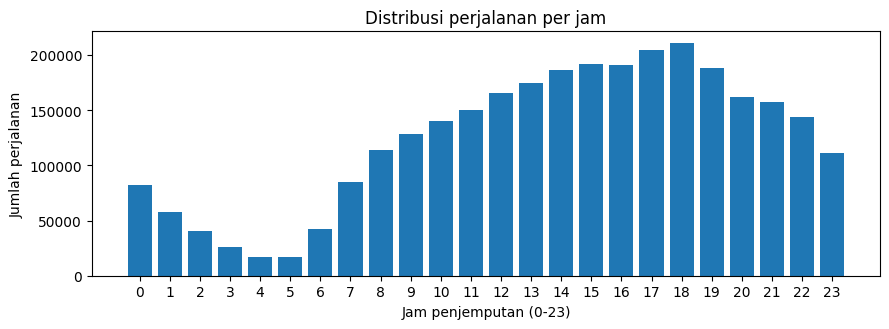

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()

fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

**LATIHAN**

LATIHAN 1

In [33]:
# Mengambil 5 perjalanan dengan trip_distance terbesar
top5_distance = (
    bersih
    .nlargest(5, "trip_distance")
)

top5_distance

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


LATIHAN 2

In [36]:
def uji_chunk(chunksize):
    start = time.perf_counter()
    rss_awal = proses.memory_info().rss / 1024**2

    total_baris = 0

    for chunk in pd.read_csv(CSV, chunksize=chunksize):
        total_baris += len(chunk)

    waktu = time.perf_counter() - start
    rss_akhir = proses.memory_info().rss / 1024**2

    return total_baris, waktu, rss_akhir - rss_awal


hasil_100k = uji_chunk(100_000)
hasil_1jt = uji_chunk(1_000_000)

print("Chunksize 100.000:", hasil_100k)
print("Chunksize 1.000.000:", hasil_1jt)

Chunksize 100.000: (2986911, 4.345572364999498, 80.58203125)
Chunksize 1.000.000: (2986911, 4.971334363999631, 184.30859375)


LATIHAN 3

/tmp/ipykernel_6140/988279855.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("payment_type")["persen_tip"]


,payment_type,persen_tip
0,0,20.22
1,1,25.91
2,2,0.00
3,3,0.02
4,4,0.15


LATIHAN 4

In [39]:
import time
import os

path_snappy = "/content/bersih_snappy.parquet"
path_gzip = "/content/bersih_gzip.parquet"

# Kompresi Snappy
start = time.perf_counter()

bersih.to_parquet(
    path_snappy,
    compression="snappy",
    index=False
)

waktu_snappy = time.perf_counter() - start

# Kompresi Gzip
start = time.perf_counter()

bersih.to_parquet(
    path_gzip,
    compression="gzip",
    index=False
)

waktu_gzip = time.perf_counter() - start

# Ukuran file
ukuran_snappy = os.path.getsize(path_snappy) / 1024**2
ukuran_gzip = os.path.getsize(path_gzip) / 1024**2

print("HASIL PERBANDINGAN KOMPRESI")
print("-" * 40)

print(f"Snappy : {ukuran_snappy:.2f} MB | {waktu_snappy:.2f} detik")
print(f"Gzip   : {ukuran_gzip:.2f} MB | {waktu_gzip:.2f} detik")

HASIL PERBANDINGAN KOMPRESI
----------------------------------------
Snappy : 63.46 MB | 1.86 detik
Gzip   : 51.02 MB | 41.06 detik


LATIHAN 5

In [11]:
sdf_bersih.createOrReplaceTempView("trips")

spark_sql_result = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah
    FROM trips
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

spark_sql_result.show(24, truncate=False)

+---+------+
|jam|jumlah|
+---+------+
|0  |82289 |
|1  |57766 |
|2  |40445 |
|3  |26146 |
|4  |16618 |
|5  |16940 |
|6  |42300 |
|7  |84569 |
|8  |114064|
|9  |127988|
|10 |140230|
|11 |150539|
|12 |165714|
|13 |174183|
|14 |186741|
|15 |191392|
|16 |190689|
|17 |204399|
|18 |210858|
|19 |188347|
|20 |161789|
|21 |157770|
|22 |143800|
|23 |111335|
+---+------+



In [16]:
# Mengubah hasil Spark SQL menjadi Pandas
spark_sql_pd = spark_sql_result.toPandas()

# Hasil agregasi Pandas dari J-9
pandas_compare = agregasi[["jam", "jumlah_perjalanan"]].copy()

# Hasil agregasi Spark SQL
spark_compare = spark_sql_pd[["jam", "jumlah"]].copy()

# Samakan nama kolom
spark_compare = spark_compare.rename(
    columns={"jumlah": "jumlah_perjalanan"}
)

# Membandingkan hasil Pandas dan Spark
perbandingan = pandas_compare.merge(
    spark_compare,
    on="jam",
    suffixes=("_pandas", "_spark")
)

# Menghitung selisih
perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"] -
    perbandingan["jumlah_perjalanan_spark"]
).abs()

display(perbandingan)

print("Selisih maksimum:", perbandingan["selisih"].max())

,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


Selisih maksimum: 0
